
# ANN Lab in FAISS: Linear Scan vs IVF vs HNSW

In [1]:

# Uncomment this only if FAISS is missing in your Kaggle runtime
!pip -q install faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 62.6 MB/s eta 0:00:00


In [2]:

import time
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import faiss

np.random.seed(42)
print("FAISS version loaded successfully")


FAISS version loaded successfully



## 1) Create a clustered vector dataset

We intentionally create clustered data because:
- it makes the difference between exact search and ANN easier to see
- IVF is built around the idea of partitioning the space into coarse cells / clusters

You can increase `NB` later if you want a more dramatic speed difference.


In [3]:

NB = 50_000    # database vectors
NQ = 500       # query vectors
D  = 128       # dimensionality
NCLUSTERS = 100
K = 10

rng = np.random.default_rng(42)

# Cluster centers
centers = rng.standard_normal((NCLUSTERS, D), dtype=np.float32)

# Database vectors: each vector belongs to one cluster + small noise
db_cluster_ids = rng.integers(0, NCLUSTERS, size=NB)
xb = centers[db_cluster_ids] + 0.05 * rng.standard_normal((NB, D), dtype=np.float32)

# Query vectors: also sampled near cluster centers
q_cluster_ids = rng.integers(0, NCLUSTERS, size=NQ)
xq = centers[q_cluster_ids] + 0.05 * rng.standard_normal((NQ, D), dtype=np.float32)

xb = xb.astype("float32")
xq = xq.astype("float32")

print("Database shape:", xb.shape)
print("Query shape:", xq.shape)


Database shape: (50000, 128)
Query shape: (500, 128)



## 2) Helper functions


In [4]:

def timed_search(index, queries, k, repeats=5):
    """Run search multiple times and return average search time."""
    # Warm-up
    index.search(queries[:10], k)

    times = []
    last_D, last_I = None, None
    for _ in range(repeats):
        t0 = perf_counter()
        D_out, I_out = index.search(queries, k)
        dt = perf_counter() - t0
        times.append(dt)
        last_D, last_I = D_out, I_out

    avg_total_s = float(np.mean(times))
    avg_ms_per_query = avg_total_s * 1000 / len(queries)
    return avg_total_s, avg_ms_per_query, last_D, last_I


def recall_at_k(I_true, I_pred, k):
    """Fraction of true top-k neighbors recovered by approximate search."""
    total_hits = 0
    for gt_row, pred_row in zip(I_true[:, :k], I_pred[:, :k]):
        total_hits += len(set(gt_row).intersection(set(pred_row)))
    return total_hits / (I_true.shape[0] * k)


def summarize_result(name, build_s, total_search_s, ms_per_query, recall):
    return {
        "index": name,
        "build_time_s": round(build_s, 4),
        "search_time_s": round(total_search_s, 4),
        "ms_per_query": round(ms_per_query, 4),
        "recall@10_vs_exact": round(recall, 4),
    }



## 3) Exact / Linear Scan baseline

This is our ground truth.  
It is **exact**, but it is also **brute force** because every query is compared against every stored vector.


In [5]:

t0 = perf_counter()
index_flat = faiss.IndexFlatL2(D)
index_flat.add(xb)
flat_build_s = perf_counter() - t0

flat_search_s, flat_ms_per_query, D_flat, I_flat = timed_search(index_flat, xq, K, repeats=5)

results = []
results.append(
    summarize_result(
        "Exact (IndexFlatL2)",
        flat_build_s,
        flat_search_s,
        flat_ms_per_query,
        recall=1.0,   # exact baseline vs itself
    )
)

print("Flat index ntotal:", index_flat.ntotal)
pd.DataFrame(results)


Flat index ntotal: 50000


,index,build_time_s,search_time_s,ms_per_query,recall@10_vs_exact
0,Exact (IndexFlatL2),0.0249,0.1689,0.3379,1.0



## 4) IVF index

### Intuition
1. Partition the vector space into `nlist` coarse cells
2. Assign each database vector to one cell
3. At query time, search only `nprobe` selected cells instead of the full database

### Key parameters
- `nlist`: how many coarse clusters / inverted lists
- `nprobe`: how many lists to visit at search time

Bigger `nprobe`:
- better recall
- slower search


In [6]:

NLIST = 256
NPROBE = 16

quantizer = faiss.IndexFlatL2(D)

t0 = perf_counter()
index_ivf = faiss.IndexIVFFlat(quantizer, D, NLIST, faiss.METRIC_L2)
index_ivf.train(xb)      # IVF must be trained
index_ivf.add(xb)
index_ivf.nprobe = NPROBE
ivf_build_s = perf_counter() - t0

ivf_search_s, ivf_ms_per_query, D_ivf, I_ivf = timed_search(index_ivf, xq, K, repeats=5)
ivf_recall = recall_at_k(I_flat, I_ivf, K)

results.append(
    summarize_result(
        f"IVF (nlist={NLIST}, nprobe={NPROBE})",
        ivf_build_s,
        ivf_search_s,
        ivf_ms_per_query,
        ivf_recall,
    )
)

print("IVF trained:", index_ivf.is_trained)
print("IVF ntotal:", index_ivf.ntotal)
pd.DataFrame(results)


IVF trained: True
IVF ntotal: 50000


,index,build_time_s,search_time_s,ms_per_query,recall@10_vs_exact
0,Exact (IndexFlatL2),0.0249,0.1689,0.3379,1.0000
1,"IVF (nlist=256, nprobe=16)",0.9057,0.0386,0.0772,0.9988



## 5) HNSW index

### Intuition
HNSW builds a **graph** over vectors.  
At query time it explores the graph to quickly move toward good neighbors.

### Key parameters
- `M`: graph connectivity
- `efConstruction`: exploration while building the graph
- `efSearch`: exploration while searching

Bigger `efSearch`:
- better recall
- slower search


In [7]:

M = 32
EF_CONSTRUCTION = 200
EF_SEARCH = 64

t0 = perf_counter()
index_hnsw = faiss.IndexHNSWFlat(D, M)
index_hnsw.hnsw.efConstruction = EF_CONSTRUCTION
index_hnsw.add(xb)   # HNSW does not require a separate train() step
index_hnsw.hnsw.efSearch = EF_SEARCH
hnsw_build_s = perf_counter() - t0

hnsw_search_s, hnsw_ms_per_query, D_hnsw, I_hnsw = timed_search(index_hnsw, xq, K, repeats=5)
hnsw_recall = recall_at_k(I_flat, I_hnsw, K)

results.append(
    summarize_result(
        f"HNSW (M={M}, efSearch={EF_SEARCH})",
        hnsw_build_s,
        hnsw_search_s,
        hnsw_ms_per_query,
        hnsw_recall,
    )
)

summary_df = pd.DataFrame(results)
summary_df


,index,build_time_s,search_time_s,ms_per_query,recall@10_vs_exact
0,Exact (IndexFlatL2),0.0249,0.1689,0.3379,1.0000
1,"IVF (nlist=256, nprobe=16)",0.9057,0.0386,0.0772,0.9988
2,"HNSW (M=32, efSearch=64)",3.4166,0.0192,0.0385,0.9986



## 6) Compare results


In [8]:

summary_df


,index,build_time_s,search_time_s,ms_per_query,recall@10_vs_exact
0,Exact (IndexFlatL2),0.0249,0.1689,0.3379,1.0000
1,"IVF (nlist=256, nprobe=16)",0.9057,0.0386,0.0772,0.9988
2,"HNSW (M=32, efSearch=64)",3.4166,0.0192,0.0385,0.9986


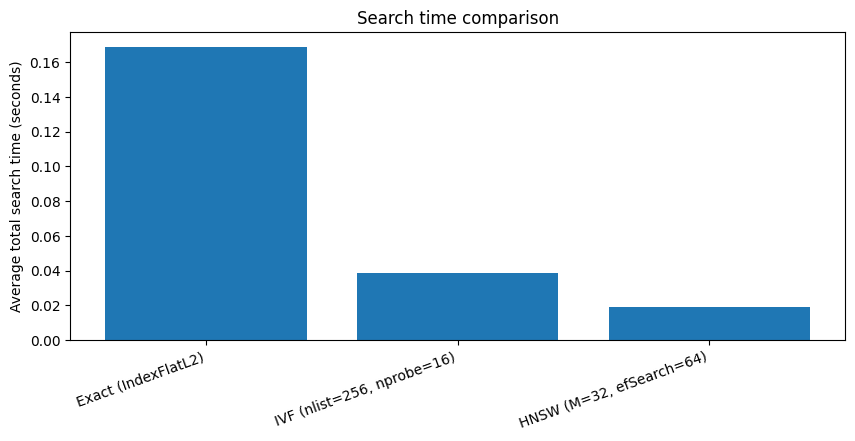

In [9]:

plt.figure(figsize=(10, 4))
plt.bar(summary_df["index"], summary_df["search_time_s"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Average total search time (seconds)")
plt.title("Search time comparison")
plt.show()


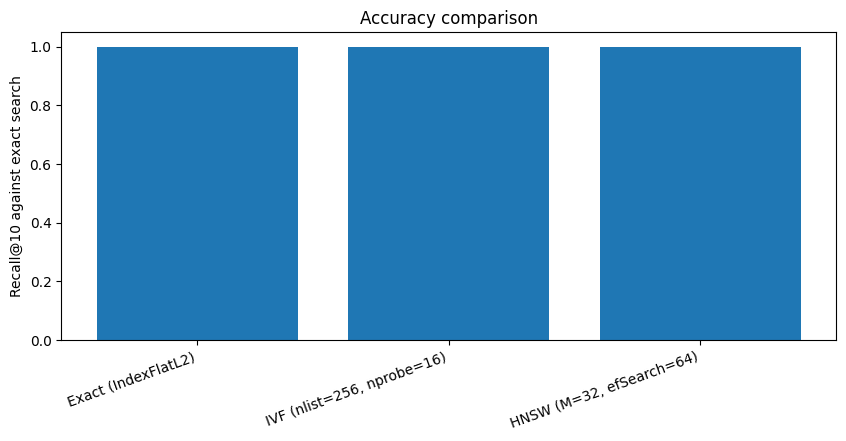

In [10]:

plt.figure(figsize=(10, 4))
plt.bar(summary_df["index"], summary_df["recall@10_vs_exact"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Recall@10 against exact search")
plt.title("Accuracy comparison")
plt.ylim(0, 1.05)
plt.show()



## 7) Optional tuning demo: IVF speed vs recall

This is excellent for class because students can see the tradeoff directly.


In [11]:

ivf_rows = []

for nprobe in [1, 2, 4, 8, 16, 32, 64]:
    index_ivf.nprobe = nprobe
    total_s, ms_q, _, I_pred = timed_search(index_ivf, xq, K, repeats=3)
    rec = recall_at_k(I_flat, I_pred, K)
    ivf_rows.append({
        "nprobe": nprobe,
        "search_time_s": total_s,
        "ms_per_query": ms_q,
        "recall@10": rec,
    })

ivf_tuning_df = pd.DataFrame(ivf_rows)
ivf_tuning_df


,nprobe,search_time_s,ms_per_query,recall@10
0,1,0.004712,0.009424,0.6440
1,2,0.006843,0.013686,0.8616
2,4,0.012303,0.024606,0.9818
3,8,0.022255,0.044510,0.9988
4,16,0.035153,0.070305,0.9988
5,32,0.061654,0.123308,0.9988
6,64,0.101584,0.203168,0.9988


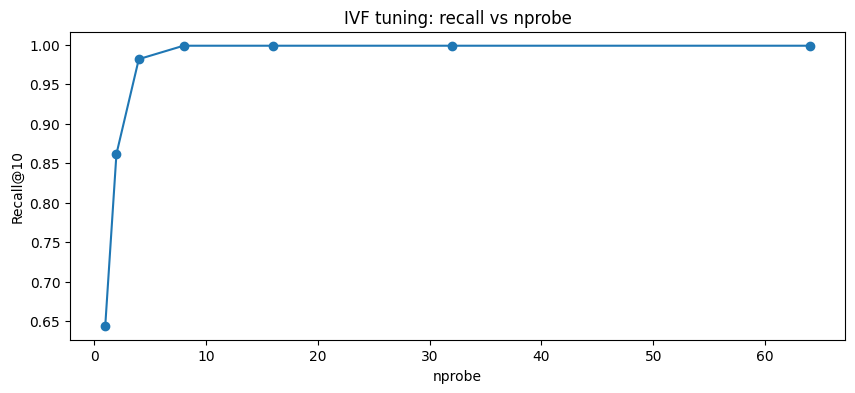

In [12]:

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(ivf_tuning_df["nprobe"], ivf_tuning_df["recall@10"], marker="o")
ax1.set_xlabel("nprobe")
ax1.set_ylabel("Recall@10")
ax1.set_title("IVF tuning: recall vs nprobe")
plt.show()



## 8) Optional tuning demo: HNSW speed vs recall


In [13]:

hnsw_rows = []

for ef_search in [8, 16, 32, 64, 128]:
    index_hnsw.hnsw.efSearch = ef_search
    total_s, ms_q, _, I_pred = timed_search(index_hnsw, xq, K, repeats=3)
    rec = recall_at_k(I_flat, I_pred, K)
    hnsw_rows.append({
        "efSearch": ef_search,
        "search_time_s": total_s,
        "ms_per_query": ms_q,
        "recall@10": rec,
    })

hnsw_tuning_df = pd.DataFrame(hnsw_rows)
hnsw_tuning_df


,efSearch,search_time_s,ms_per_query,recall@10
0,8,0.007127,0.014255,0.8070
1,16,0.009739,0.019477,0.9216
2,32,0.013604,0.027207,0.9802
3,64,0.018752,0.037505,0.9986
4,128,0.025013,0.050025,0.9988


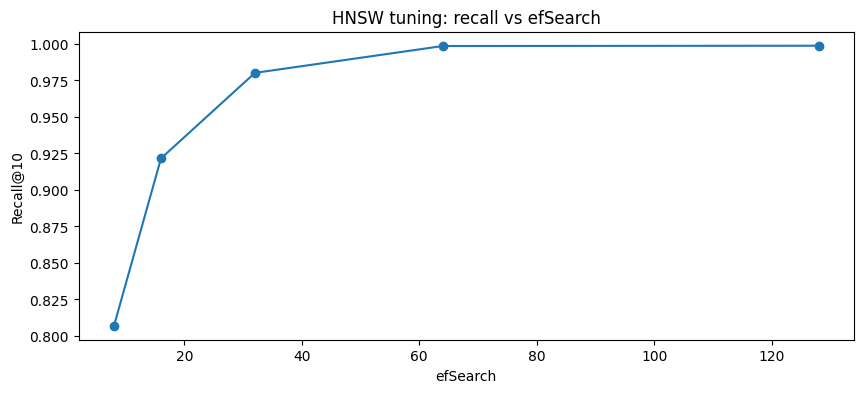

In [14]:

plt.figure(figsize=(10, 4))
plt.plot(hnsw_tuning_df["efSearch"], hnsw_tuning_df["recall@10"], marker="o")
plt.xlabel("efSearch")
plt.ylabel("Recall@10")
plt.title("HNSW tuning: recall vs efSearch")
plt.show()



## 9) What to say while presenting

### Exact / Linear scan
- This is the baseline.
- It is accurate because it checks everything.
- But it becomes expensive as the database grows.

### IVF
- We first cluster the space coarsely.
- At query time we do **not** search all clusters.
- We search only a few likely clusters.
- This cuts search cost a lot.
- If the true neighbor is in an unvisited cluster, recall drops.

### HNSW
- We build a graph over vectors.
- Search “navigates” the graph toward promising neighbors.
- It is often very fast and high-recall.
- But it needs extra graph memory and build time.

### Final takeaway
- Exact search = best accuracy, worst scalability
- IVF = cluster-based ANN
- HNSW = graph-based ANN
- ANN is about **speed–accuracy tradeoff**



## 10) If you want cosine similarity instead of L2

This notebook uses **L2 distance** for stability and clarity.

For cosine similarity in FAISS:
1. normalize database vectors
2. normalize query vectors
3. use an inner-product index such as `IndexFlatIP`

Example:
```python
faiss.normalize_L2(xb)
faiss.normalize_L2(xq)
index = faiss.IndexFlatIP(D)
```

You can make the same change for IVF as well by using `METRIC_INNER_PRODUCT`.
